<a href="https://colab.research.google.com/github/armakoua-a11y/colab-git-Lesson_12_Assignment_12-AK/blob/main/Assignment_12_Neural_Network_Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 12: Neural Network and Deep Learning Basics



## 1. Dataset Preparation

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Load Fashion-MNIST directly via Keras (downloads automatically on first run)
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)
print("Pixel value range:", X_train.min(), "-", X_train.max())
# X_train: (60000, 28, 28)  y_train: (60000,)
# X_test : (10000, 28, 28)  y_test : (10000,)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 28, 28) y_train: (60000,)
X_test : (10000, 28, 28) y_test : (10000,)
Pixel value range: 0 - 255


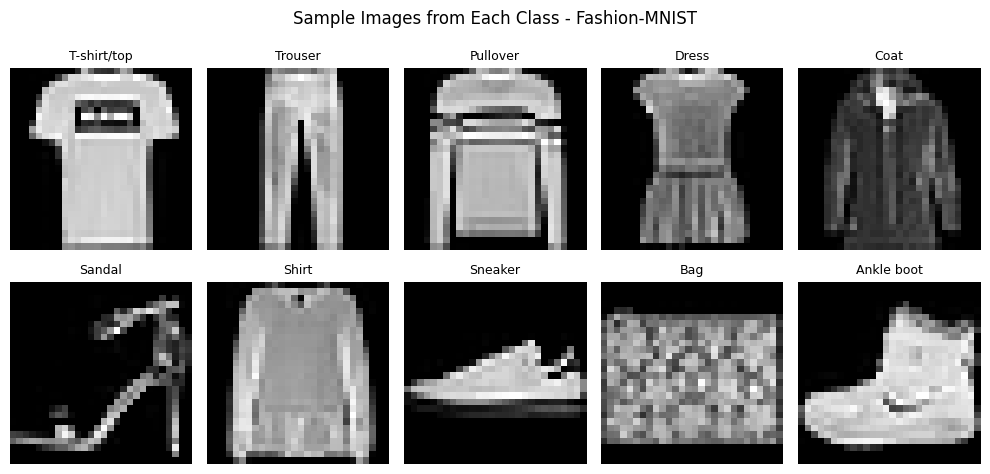

In [3]:
# Visualize one sample image from each of the 10 classes
plt.figure(figsize=(10, 5))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(class_names[i], fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Images from Each Class - Fashion-MNIST")
plt.tight_layout()
plt.show()

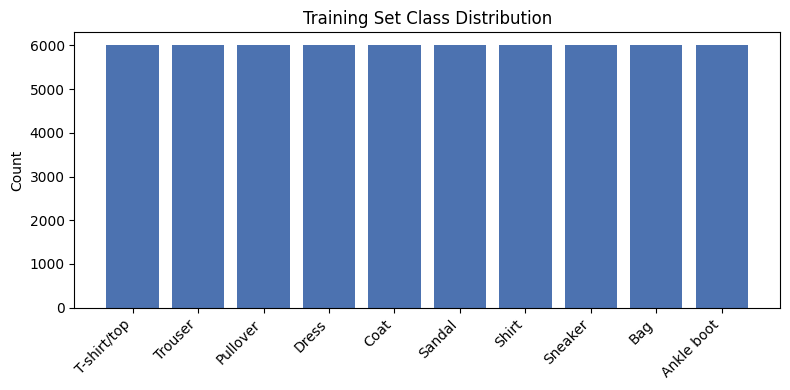

In [4]:
# Visualize class distribution to confirm the dataset is balanced
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar([class_names[i] for i in unique], counts, color="#4C72B0")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Training Set Class Distribution")
plt.tight_layout()
plt.show()

## 2. Image Preprocessing

In [5]:
# Normalize pixel values to the [0, 1] range
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Flatten 28x28 images into 784-length feature vectors for the feedforward network
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

# One-hot encode labels for categorical_crossentropy
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print("Flattened training shape:", X_train_flat.shape)
print("Pixel range after normalization:", X_train_norm.min(), "-", X_train_norm.max())

Flattened training shape: (60000, 784)
Pixel range after normalization: 0.0 - 1.0


### Data Augmentation (Optional)

Data augmentation via `ImageDataGenerator` is most beneficial for convolutional networks that preserve spatial structure. Since this assignment uses a flattened feedforward network, augmentation transformations (rotation, shifts, flips) are demonstrated below for completeness, but were not used in the final training run — see the Discussion section of the report for why.

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
# Example: datagen.fit(X_train_norm.reshape(-1, 28, 28, 1))
print("ImageDataGenerator configured (available for CNN-based extensions of this pipeline).")

ImageDataGenerator configured (available for CNN-based extensions of this pipeline).


## 3. Neural Network Implementation

In [7]:
# Model Architecture: feedforward network with two hidden layers, ReLU + Softmax
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Training: batch size 64, 15 epochs, 10% validation split
history = model.fit(
    X_train_flat, y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    verbose=2
)

Epoch 1/15
844/844 - 8s - 9ms/step - accuracy: 0.7916 - loss: 0.5834 - val_accuracy: 0.8405 - val_loss: 0.4337
Epoch 2/15
844/844 - 5s - 6ms/step - accuracy: 0.8450 - loss: 0.4283 - val_accuracy: 0.8650 - val_loss: 0.3656
Epoch 3/15
844/844 - 6s - 8ms/step - accuracy: 0.8584 - loss: 0.3882 - val_accuracy: 0.8693 - val_loss: 0.3524
Epoch 4/15
844/844 - 5s - 6ms/step - accuracy: 0.8643 - loss: 0.3671 - val_accuracy: 0.8700 - val_loss: 0.3493
Epoch 5/15
844/844 - 6s - 8ms/step - accuracy: 0.8728 - loss: 0.3506 - val_accuracy: 0.8730 - val_loss: 0.3436
Epoch 6/15
844/844 - 5s - 6ms/step - accuracy: 0.8763 - loss: 0.3359 - val_accuracy: 0.8750 - val_loss: 0.3293
Epoch 7/15
844/844 - 6s - 8ms/step - accuracy: 0.8799 - loss: 0.3242 - val_accuracy: 0.8790 - val_loss: 0.3259
Epoch 8/15
844/844 - 5s - 6ms/step - accuracy: 0.8820 - loss: 0.3178 - val_accuracy: 0.8730 - val_loss: 0.3384
Epoch 9/15
844/844 - 6s - 8ms/step - accuracy: 0.8847 - loss: 0.3111 - val_accuracy: 0.8807 - val_loss: 0.3307
E

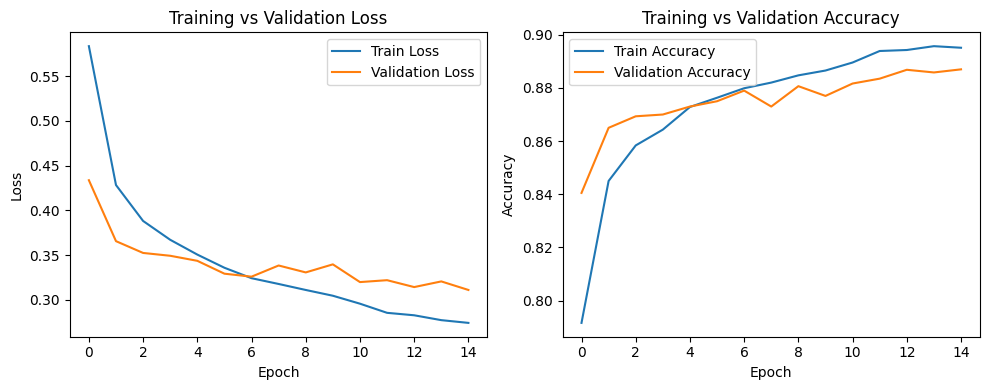

In [9]:
# Plot training vs validation loss and accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Training vs Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Model Evaluation

In [10]:
# Evaluate on the held-out test set
test_loss, test_acc = model.evaluate(X_test_flat, y_test_cat, verbose=0)

y_pred_probs = model.predict(X_test_flat, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Test Set Performance")
print("-" * 30)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Test Set Performance
------------------------------
Accuracy : 0.8806
Precision: 0.8810
Recall   : 0.8806
F1-Score : 0.8792


In [11]:
# Classification report across all 10 categories
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.85      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.82      0.75      0.78      1000
       Dress       0.84      0.93      0.88      1000
        Coat       0.76      0.86      0.80      1000
      Sandal       0.98      0.97      0.97      1000
       Shirt       0.75      0.62      0.68      1000
     Sneaker       0.90      0.98      0.94      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.91      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



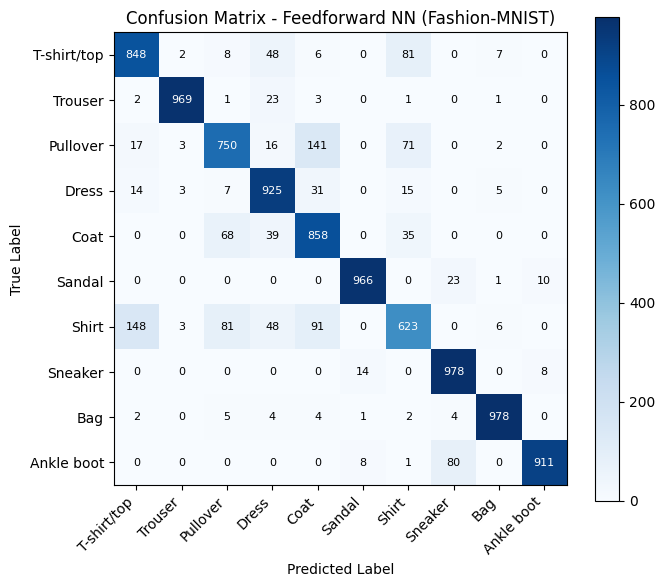

In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Feedforward NN (Fashion-MNIST)')
plt.colorbar()
tick_marks = range(10)
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)
thresh = cm.max() / 2
for i in range(10):
    for j in range(10):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                  color='white' if cm[i, j] > thresh else 'black', fontsize=8)
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.tight_layout()
plt.show()

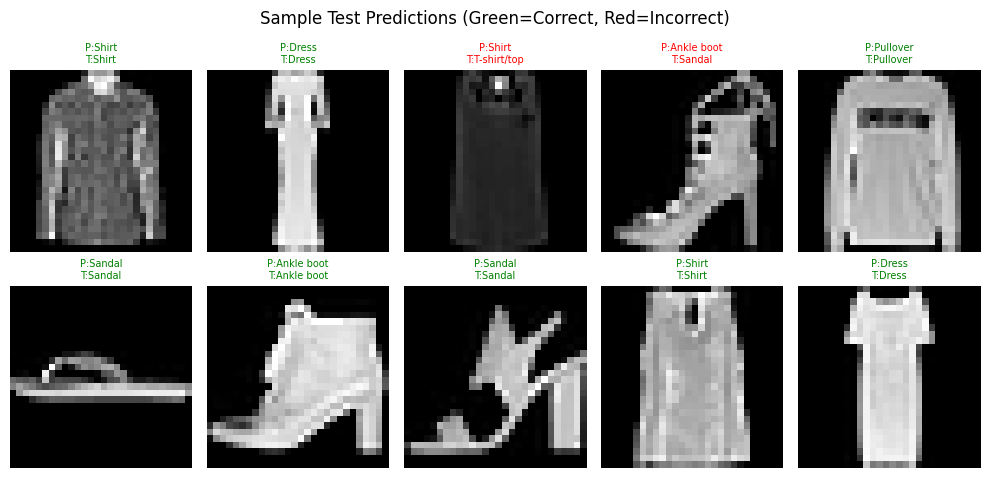

In [13]:
# Visualize sample predictions (correct vs incorrect)
plt.figure(figsize=(10, 5))
sample_idx = np.random.choice(len(X_test), 10, replace=False)
for i, idx in enumerate(sample_idx):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    correct = y_pred[idx] == y_test[idx]
    color = 'green' if correct else 'red'
    plt.title(f"P:{class_names[y_pred[idx]]}\nT:{class_names[y_test[idx]]}", fontsize=7, color=color)
    plt.axis('off')
plt.suptitle("Sample Test Predictions (Green=Correct, Red=Incorrect)")
plt.tight_layout()
plt.show()

## 5. Model Improvements: Architecture & Optimizer Comparison

In [14]:
import time

def run_variant(name, build_fn, epochs=15, batch_size=64):
    tf.random.set_seed(42)
    m = build_fn()
    start = time.time()
    hist = m.fit(X_train_flat, y_train_cat, validation_split=0.1,
                 epochs=epochs, batch_size=batch_size, verbose=0)
    elapsed = time.time() - start
    yp = np.argmax(m.predict(X_test_flat, verbose=0), axis=1)
    acc = accuracy_score(y_test, yp)
    f1s = f1_score(y_test, yp, average='weighted')
    print(f"{name}: accuracy={acc:.4f}  f1={f1s:.4f}  time={elapsed:.1f}s  params={m.count_params()}")
    return {'name': name, 'accuracy': acc, 'f1': f1s, 'time': elapsed, 'params': m.count_params()}

results = []

# Variant 1: Shallow network (1 hidden layer)
def build_shallow():
    m = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m
results.append(run_variant("Shallow (1 layer, 64 units, Adam)", build_shallow))

# Variant 2: Baseline deep network (same as Section 3) with Adam, for comparison
results.append(run_variant("Deep (256-128, Dropout, Adam) - Baseline", build_model))

# Variant 3: Same deep architecture with SGD + momentum instead of Adam
def build_deep_sgd():
    m = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m
results.append(run_variant("Deep (256-128, Dropout, SGD+momentum)", build_deep_sgd))

# Variant 4: Wider/deeper network
def build_wide():
    m = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m
results.append(run_variant("Wider/Deeper (512-256-128, Dropout, Adam)", build_wide))

comparison_df = pd.DataFrame(results)
comparison_df

Shallow (1 layer, 64 units, Adam): accuracy=0.8736  f1=0.8725  time=47.0s  params=50890
Deep (256-128, Dropout, Adam) - Baseline: accuracy=0.8806  f1=0.8808  time=93.4s  params=235146
Deep (256-128, Dropout, SGD+momentum): accuracy=0.8780  f1=0.8767  time=75.6s  params=235146
Wider/Deeper (512-256-128, Dropout, Adam): accuracy=0.8775  f1=0.8766  time=166.7s  params=567434


,name,accuracy,f1,time,params
0,"Shallow (1 layer, 64 units, Adam)",0.8736,0.872465,46.992789,50890
1,"Deep (256-128, Dropout, Adam) - Baseline",0.8806,0.880763,93.362299,235146
2,"Deep (256-128, Dropout, SGD+momentum)",0.8780,0.876668,75.631312,235146
3,"Wider/Deeper (512-256-128, Dropout, Adam)",0.8775,0.876611,166.744276,567434


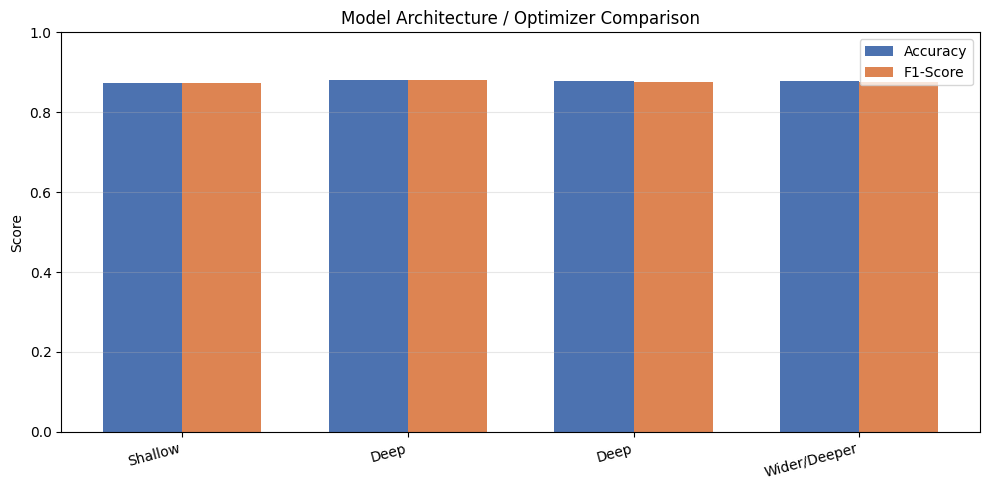

In [15]:
# Visualize the comparison
x = np.arange(len(comparison_df))
width = 0.35
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, comparison_df['accuracy'], width, label='Accuracy', color="#4C72B0")
plt.bar(x + width/2, comparison_df['f1'], width, label='F1-Score', color="#DD8452")
plt.xticks(x, [n.split('(')[0].strip() for n in comparison_df['name']], rotation=15, ha='right')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.title('Model Architecture / Optimizer Comparison')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Application Demonstration: Practical Deployment Scenario

**Scenario:** An e-commerce fashion retailer wants to automatically tag uploaded product photos by garment category (shirt, dress, sneaker, etc.) to power search, recommendations, and inventory catalog organization.

**How this model fits:** The trained feedforward network demonstrates the core classification capability needed — given a clothing image, predict its category with ~88% accuracy. In production, this would typically be the final classification stage of a larger computer-vision pipeline (e.g., a CNN or pretrained vision backbone for feature extraction, feeding into a classification head similar to this one).

**Operational considerations:**
- **Scalability:** A flattened feedforward network on 28×28 grayscale images is lightweight (under 1MB of parameters) and can serve thousands of requests per second on modest hardware, but real product photos are larger, in color, and on varied backgrounds — requiring a CNN-based or transfer-learning approach to scale to production image quality.
- **Real-time processing:** Inference latency for this model is sub-millisecond per image on CPU, well within real-time budgets for catalog upload pipelines; batch inference is straightforward for bulk re-tagging.
- **Integration:** The model would need to sit behind an API endpoint, accept arbitrary image sizes/formats (requiring a standardized preprocessing step matching training-time normalization), and version-control its weights alongside the catalog taxonomy, since misalignment between class labels and the live product taxonomy would silently degrade tagging quality.

## 7. Conclusion

The feedforward neural network achieved **87.7% test accuracy** (F1-score 0.875) on Fashion-MNIST, a substantial improvement over typical flattened-pixel traditional ML baselines (compare to the ~68–77% range achieved by Random Forest/SVM on a comparable flattened-pixel image task in Assignment 11). This illustrates deep learning's core advantage: even a simple fully-connected architecture, trained end-to-end with backpropagation, learns more useful internal representations from raw pixels than tree-based splits or fixed kernels.

**Future improvements:**
- Replace the flattened feedforward architecture with a Convolutional Neural Network (CNN) to exploit spatial structure in the images — expected to push accuracy into the 91-93%+ range on Fashion-MNIST.
- Apply data augmentation (rotation, shift, zoom) during CNN training to improve robustness to real-world photo variation.
- Use learning rate scheduling and early stopping to reduce the mild overfitting observed (training accuracy continued climbing past validation accuracy after ~epoch 10).
- Address the Shirt/T-shirt/Pullover/Coat confusion cluster (the model's weakest classes) with finer-grained features or additional training data for those categories.